In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

## Load the data

In [10]:
Employee = pd.read_csv("/Users/hedyji/Desktop/archive/Employee.csv")
SatisfiedLevel = pd.read_csv("/Users/hedyji/Desktop/archive/SatisfiedLevel.csv")
PerformanceRating = pd.read_csv("/Users/hedyji/Desktop/archive/PerformanceRating.csv")
EducationLevel = pd.read_csv("/Users/hedyji/Desktop/archive/EducationLevel.csv")
RatingLevel = pd.read_csv("/Users/hedyji/Desktop/archive/RatingLevel.csv")

Employee.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


In [11]:
# 选择最后一次员工绩效评级数据作为参考
PerformanceRating['ReviewDate'] = pd.to_datetime(PerformanceRating['ReviewDate'])
PerformanceRating.head()

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,2013-01-02,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,2013-01-03,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,2013-01-03,3,4,5,3,2,3,5,4
3,PR04,0678-748A,2013-01-04,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,2013-01-04,5,2,3,1,0,4,4,3


In [12]:
last_PerformanceRating = PerformanceRating.sort_values(['EmployeeID','ReviewDate' ]).reset_index(drop = True)
last_PerformanceRating = last_PerformanceRating.drop_duplicates('EmployeeID',keep='last')

In [13]:
# 合并员工基本信息和最后一次绩效评级数据
df = pd.merge(Employee, last_PerformanceRating, on = 'EmployeeID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   EmployeeID                       1470 non-null   object        
 1   FirstName                        1470 non-null   object        
 2   LastName                         1470 non-null   object        
 3   Gender                           1470 non-null   object        
 4   Age                              1470 non-null   int64         
 5   BusinessTravel                   1470 non-null   object        
 6   Department                       1470 non-null   object        
 7   DistanceFromHome (KM)            1470 non-null   int64         
 8   State                            1470 non-null   object        
 9   Ethnicity                        1470 non-null   object        
 10  Education                        1470 non-null   int64      

In [14]:
# 没有绩效评级员工的离职意愿都是no
df[df['PerformanceID'].isnull()]['Attrition'].value_counts()

Attrition
No    190
Name: count, dtype: int64

In [15]:
# 过滤还没有绩效评级的员工
df = df.dropna()
df.shape

(1280, 33)

## 探索性分析

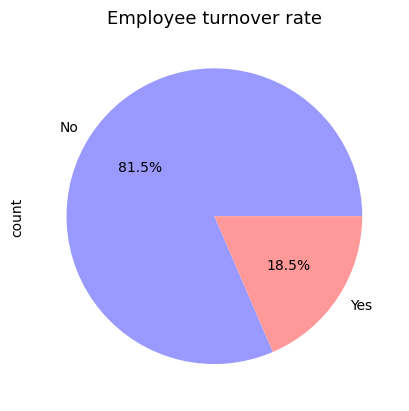

In [16]:
colors=['#9999ff','#ff9999','#7777aa','#2442aa','#dd5555']

# 统计流失员工的比率
df['Attrition'].value_counts().plot.pie(autopct='%1.1f%%',colors = colors)
plt.title("Employee turnover rate", size = 13)
plt.show()

In [17]:
# 合并一些岗位标签
def label_JobRole(JobRole):
    if 'Manager' in JobRole:
        return 'Manager'
    elif "HR" in JobRole:
        return 'HR'
    else:
        return JobRole
    
df['JobRole'] = df['JobRole'].apply(label_JobRole)

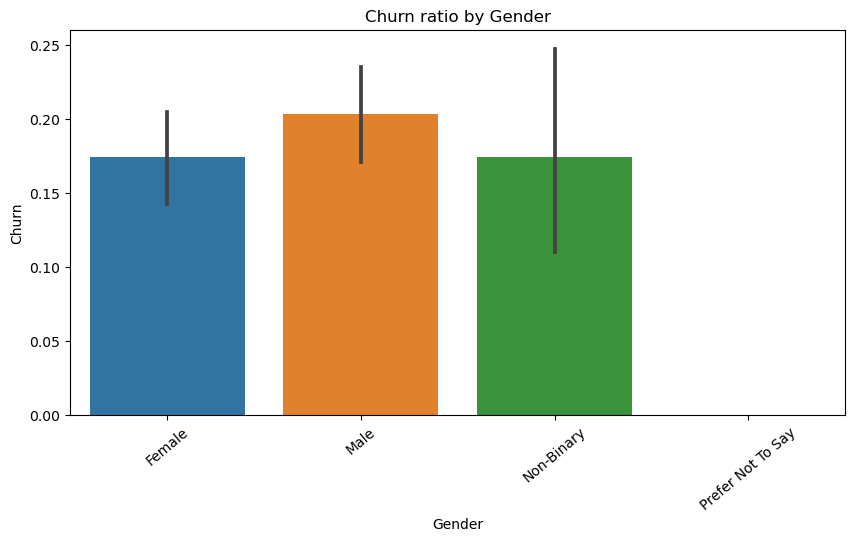

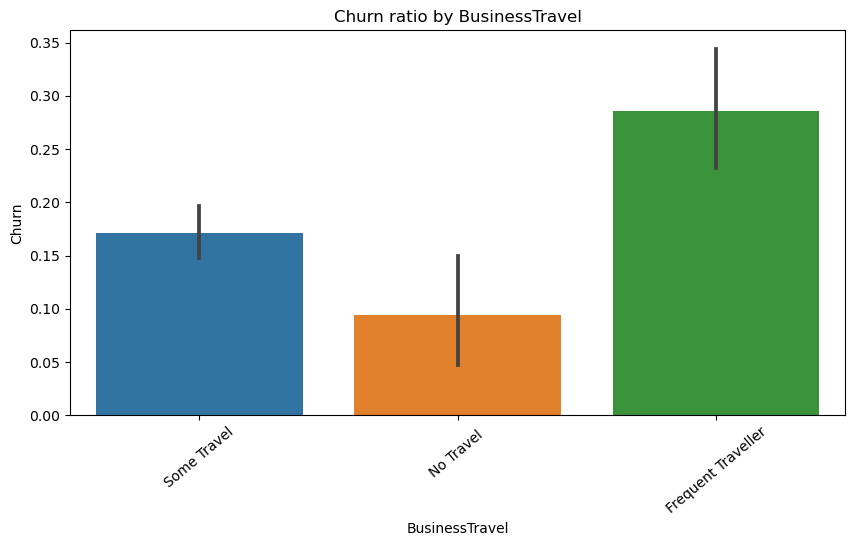

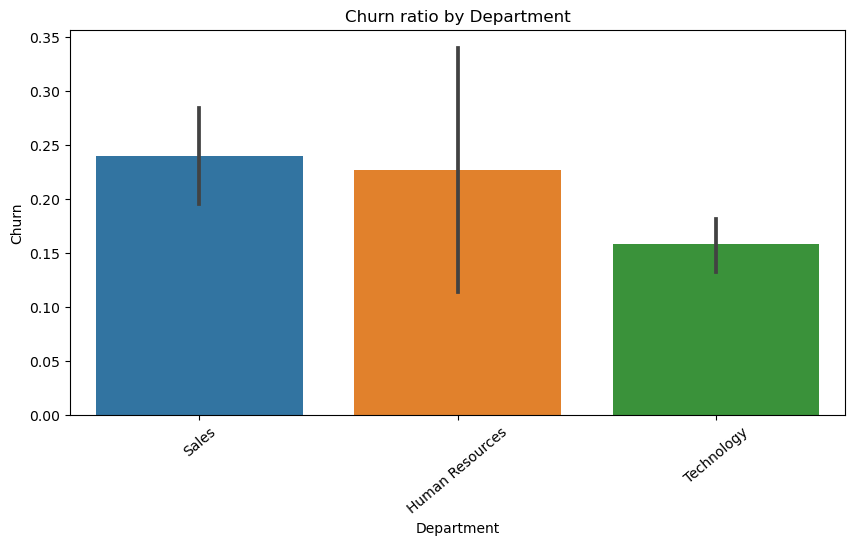

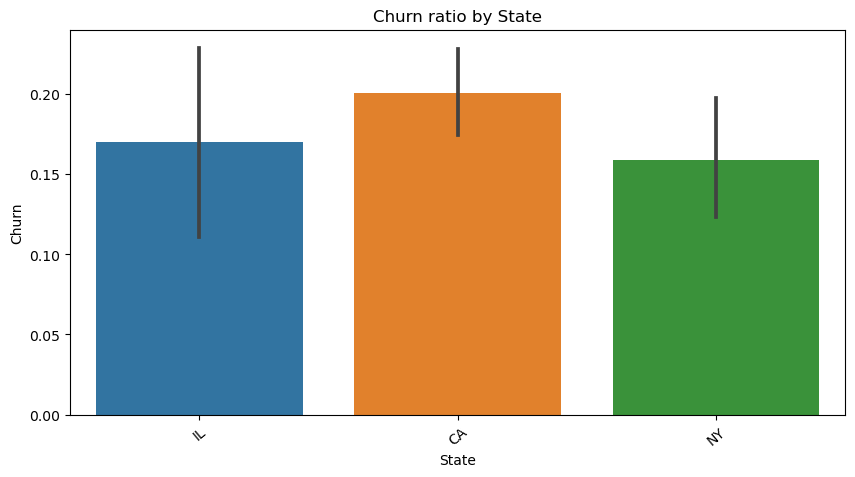

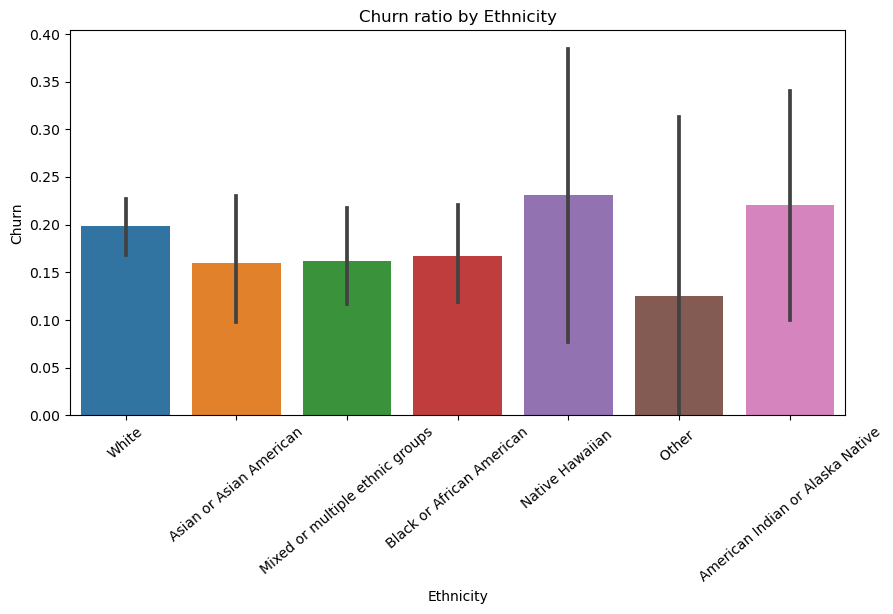

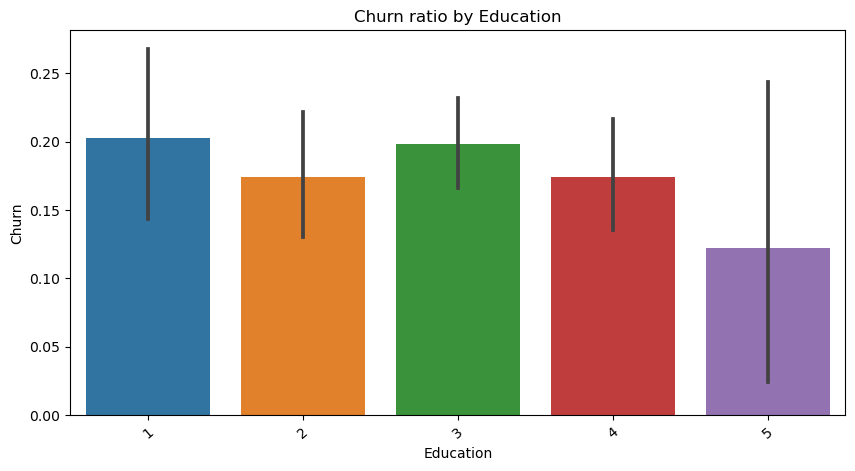

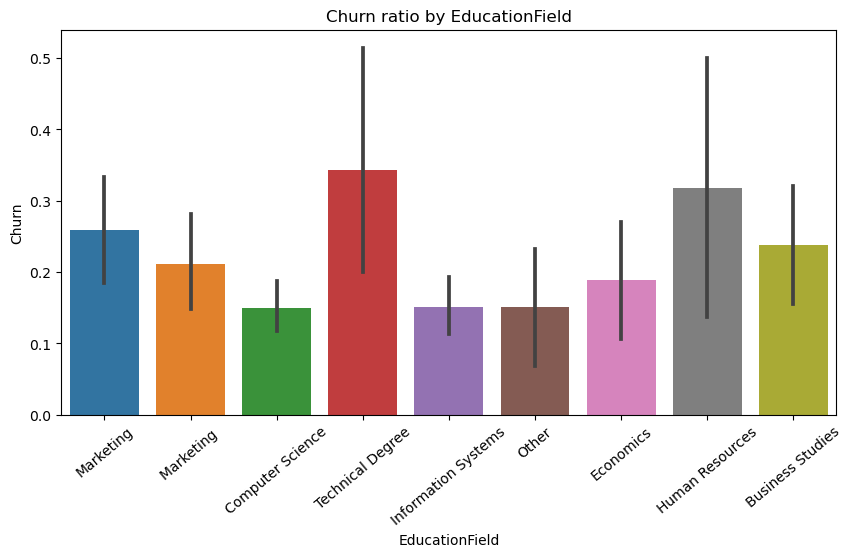

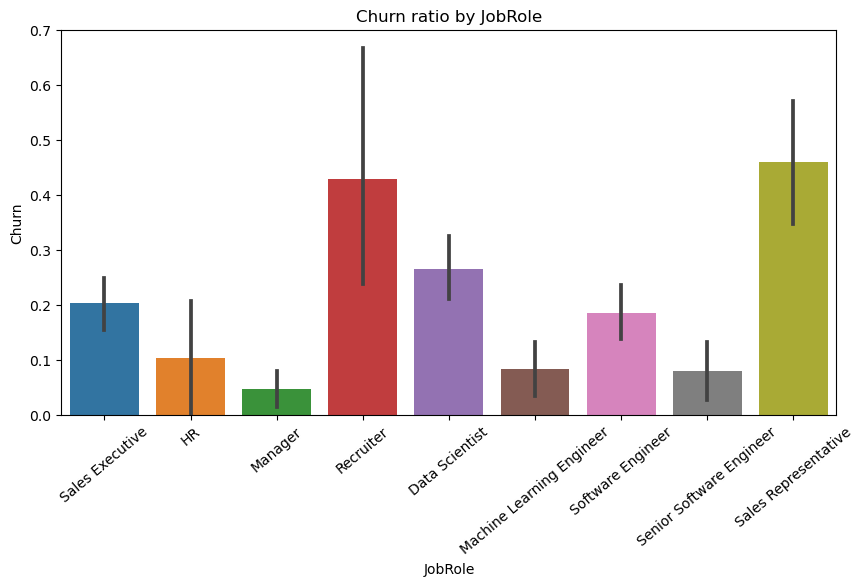

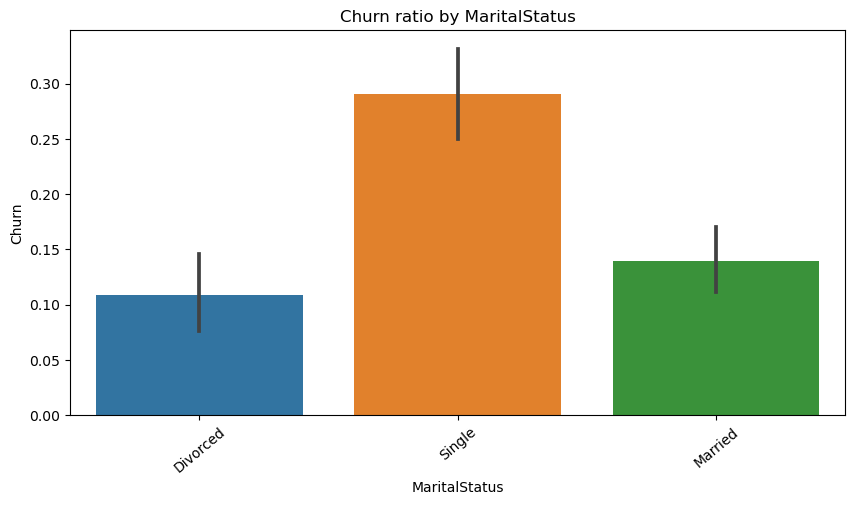

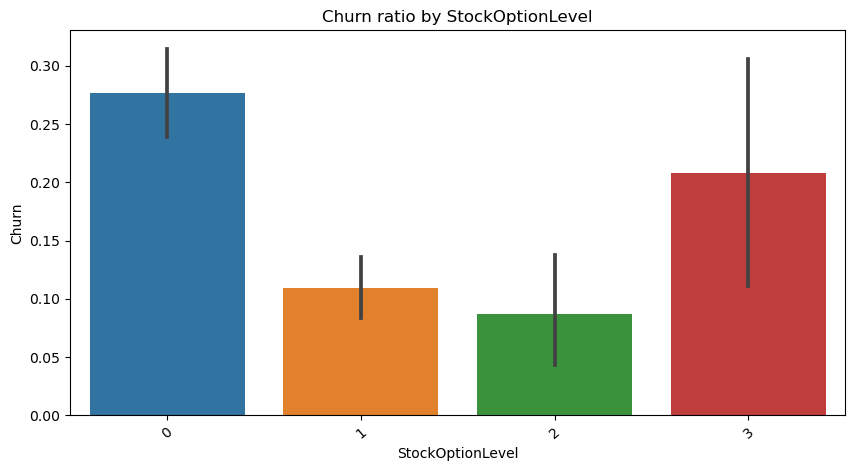

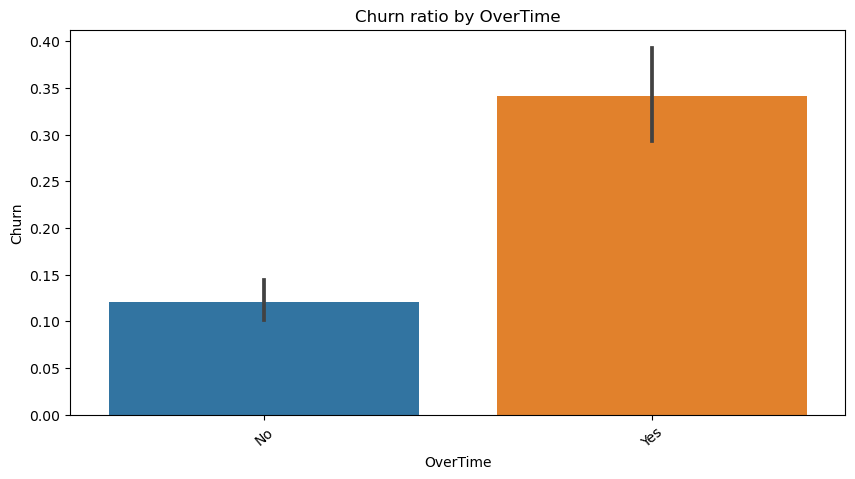

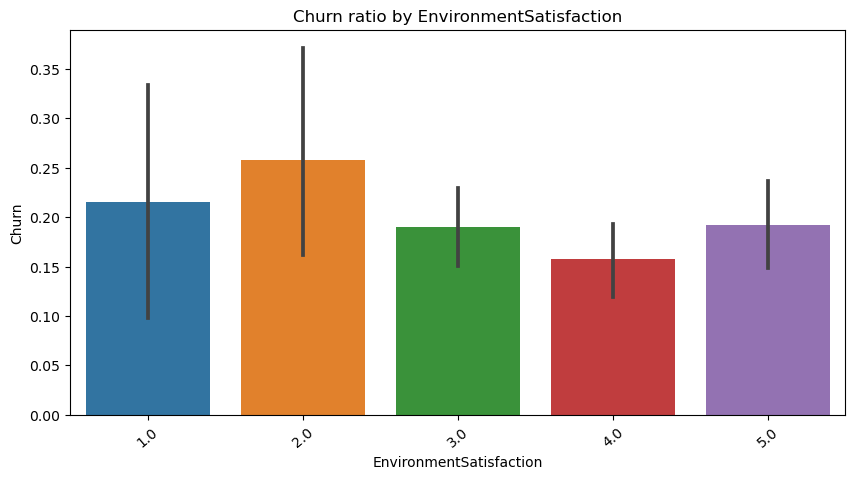

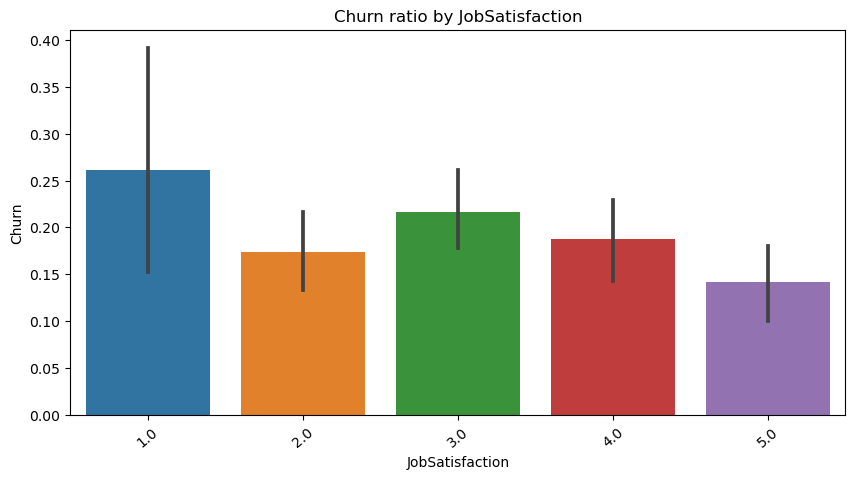

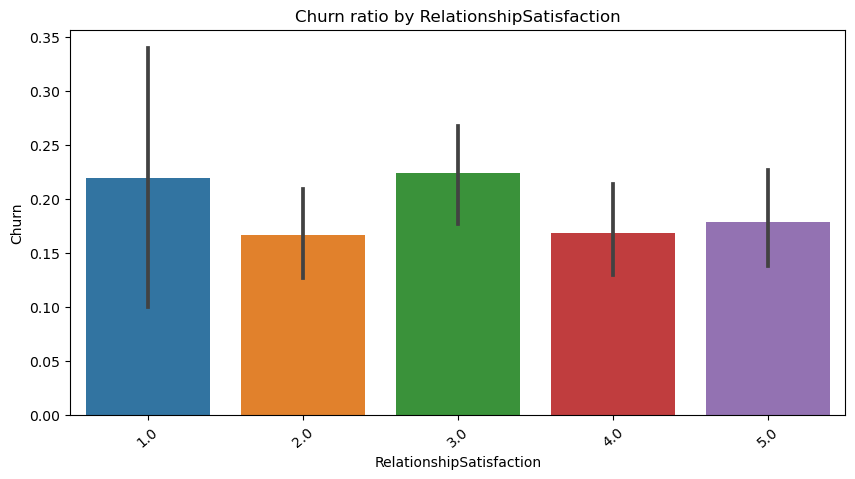

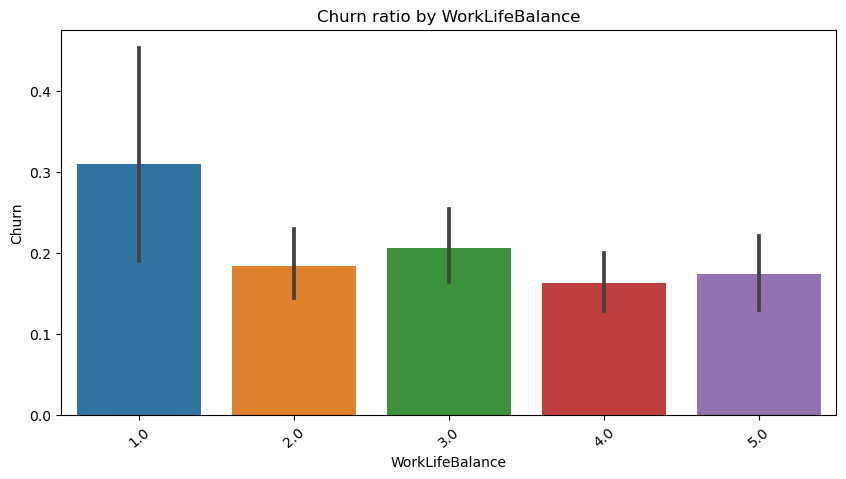

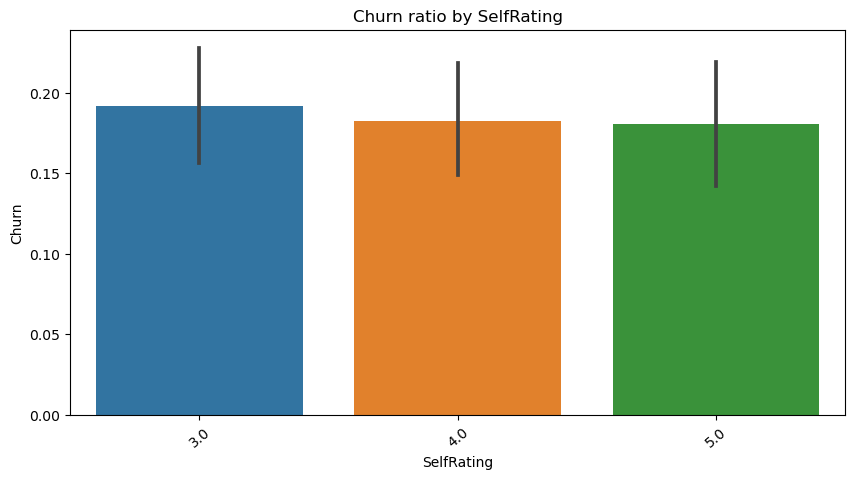

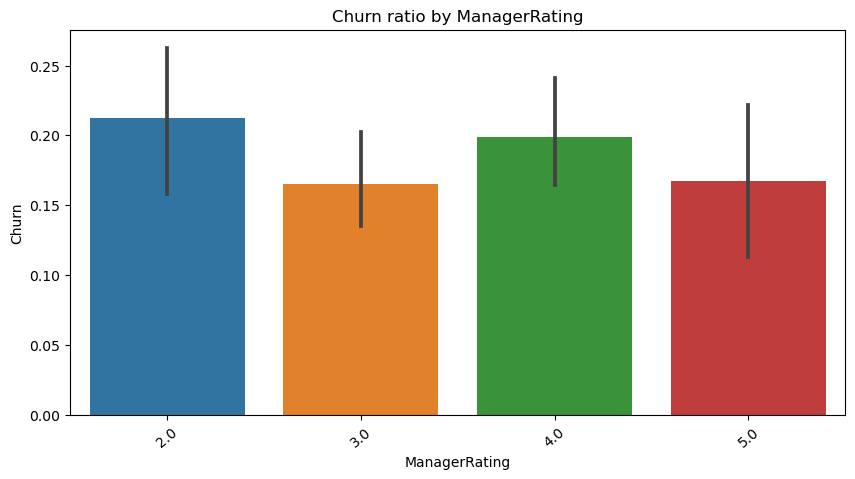

In [18]:
# 不同群体员工的流失率对比
categorical_variables = ['Gender', 'BusinessTravel', 'Department', 'State',
                         'Ethnicity', 'Education', 'EducationField',
                         'JobRole', 'MaritalStatus', 'StockOptionLevel',
                         'OverTime', 'EnvironmentSatisfaction', 'JobSatisfaction',
                         'RelationshipSatisfaction', 'WorkLifeBalance', 'SelfRating',
                         'ManagerRating']

df['Churn'] = (df['Attrition'] == 'Yes').astype(int)
for col in categorical_variables:
    plt.figure(figsize = (10,5))
    sns.barplot(x = col, y = 'Churn', data = df)
    plt.title("Churn ratio by {}".format(col))
    plt.xticks(rotation = 40)
    plt.show()

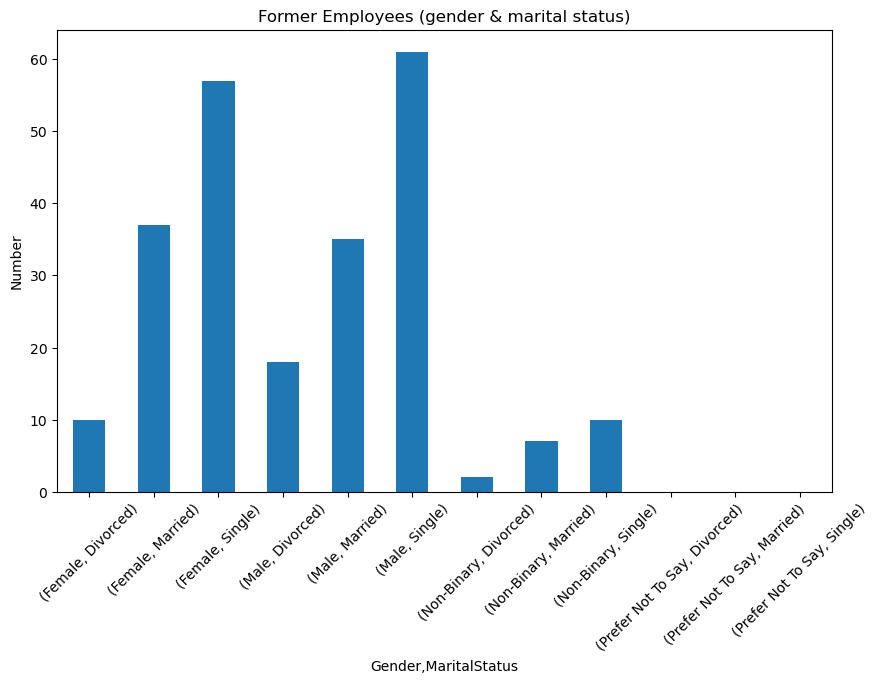

In [47]:
# 数据准备 - 只选择Attrition为No的数据
cross_counts = pd.crosstab(
    index=[df['Gender'], df['MaritalStatus']],
    columns=df['Attrition']
)

# 只取Attrition='No'的列
retained_data = cross_counts['Yes']

# 柱状图（非堆叠，因为只有一列数据）
retained_data.plot(kind='bar', figsize=(10,6))
plt.title("Former Employees (gender & marital status)")
plt.ylabel("Number")
plt.xticks(rotation=45)
plt.show()

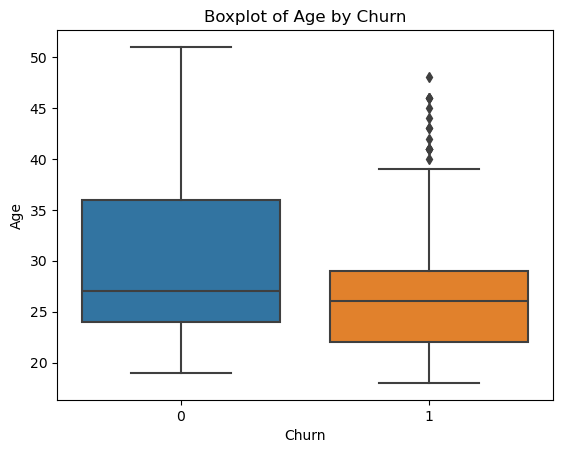

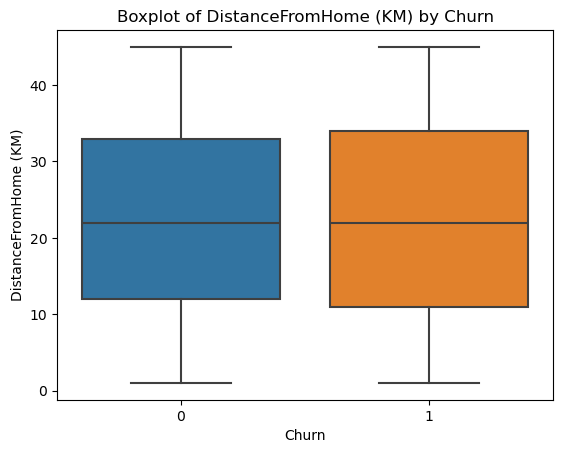

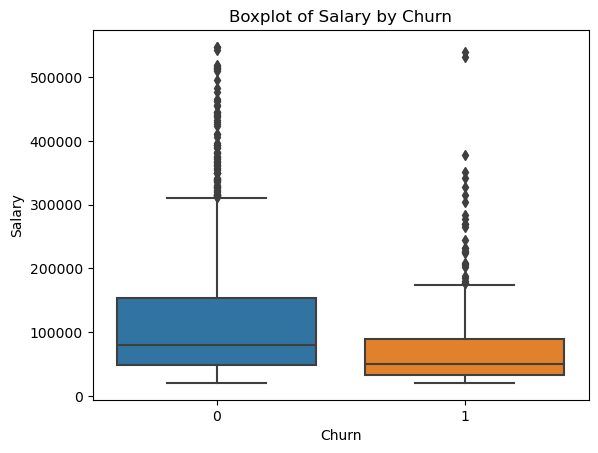

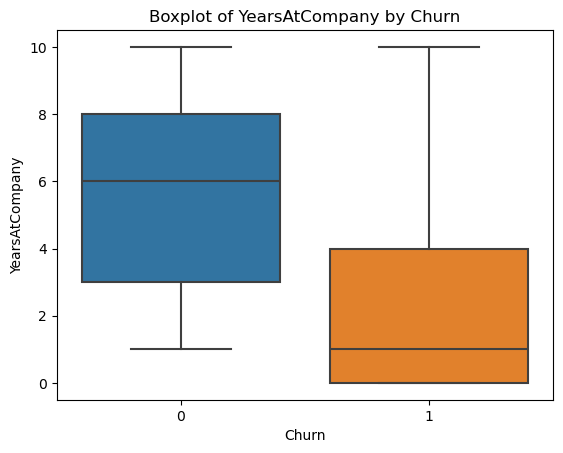

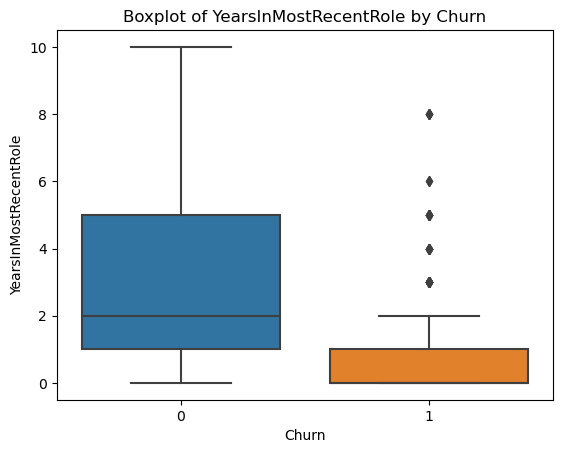

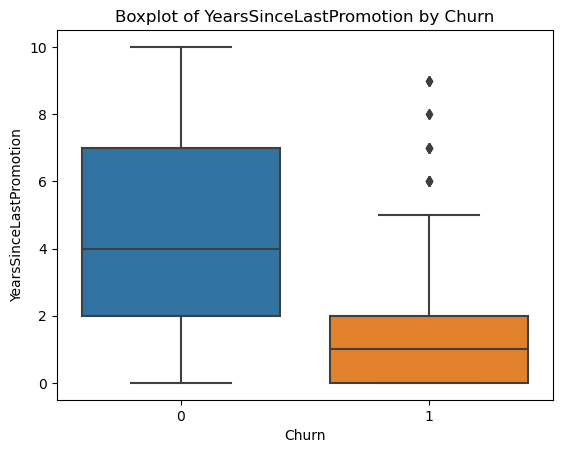

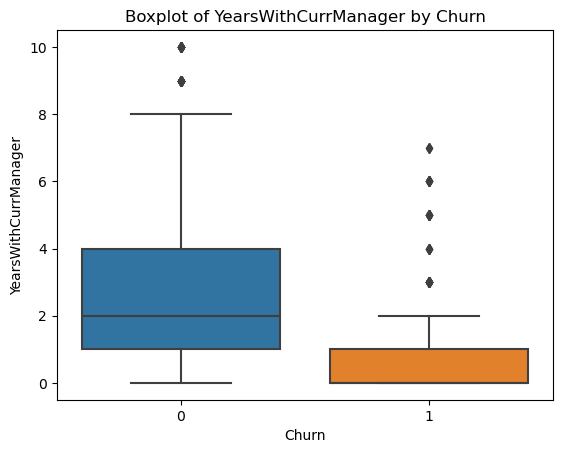

In [19]:
Numeric_variables = ['Age', 'DistanceFromHome (KM)', 'Salary', 'YearsAtCompany',
                    'YearsInMostRecentRole', 'YearsSinceLastPromotion', 
                    'YearsWithCurrManager' ]

for col in Numeric_variables:
    sns.boxplot(x = 'Churn', y = col, data = df)
    plt.title("Boxplot of {} by Churn".format(col))
    plt.show()

## 数据集划分

In [20]:
features = categorical_variables + Numeric_variables
X = df[features]
y = df['Churn']

# 对类别变量进行One-Hot编码
X = X.replace('Yes', 1).replace('No', 0)
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.7)

Scaler = MinMaxScaler()
Scaler.fit(X_train)
X_train = Scaler.transform(X_train)
X_test = Scaler.transform(X_test)

## 模型
### 逻辑回归

In [21]:
# 逻辑回归
Log = LogisticRegression()
Log.fit(X_train, y_train)

y_train_proba = Log.predict_proba(X_train)[:,1]
y_test_proba = Log.predict_proba(X_test)[:,1]

threshold = 0.5
y_train_pred = np.where(y_train_proba > threshold , 1 , 0 )
y_test_pred = np.where(y_test_proba > threshold , 1 , 0 )

train_confusion_matrix = confusion_matrix(y_train, y_train_pred)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
fpr,tpr,threshold = roc_curve(y_train, y_train_proba)
train_auc = auc(fpr,tpr)

test_confusion_matrix = confusion_matrix(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
fpr,tpr,threshold = roc_curve(y_test, y_test_proba)
test_auc = auc(fpr,tpr)

train_scores = [train_accuracy, train_precision, train_recall, 
               train_f1, train_auc]

test_scores = [test_accuracy, test_precision, test_recall, 
               test_f1, test_auc]

Log_score_df = pd.DataFrame({"Train": train_scores, 
                        'Test': test_scores}, 
                       index = ['accuracy', 'precision', 'recall',
                               'F1', 'AUC'])
Log_score_df

,Train,Test
accuracy,0.892857,0.898438
precision,0.808696,0.816327
recall,0.556886,0.571429
F1,0.659574,0.672269
AUC,0.909128,0.916197
